# Medical Appointment No-Show Prediction

**Dataset**: KaggleV2-May-2016.csv (110,527 appointments from Brazil)

**Business Goal**: Predict whether a patient will miss their scheduled appointment (`target = 1` = No-Show).

No-shows cost clinics millions in lost revenue, wasted doctor time, and poorer patient outcomes. Accurate prediction allows clinics to:
- Send targeted SMS reminders
- Overbook strategically
- Prioritize high-risk patients

**Key Insight**: Patient history (previous no-shows) + waiting time are extremely predictive.

This notebook uses **XGBoost with native categorical support** for speed and accuracy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import xgboost as xgb

pd.set_option('display.max_columns', 50)
sns.set(style="whitegrid")
%matplotlib inline

## 1. Load & Explore Data

In [2]:
df = pd.read_csv('KaggleV2-May-2016.csv', parse_dates=['ScheduledDay', 'AppointmentDay'])

print('Shape:', df.shape)
print('No-show rate:', df['No-show'].value_counts(normalize=True).round(4))

Shape: (110527, 14)
No-show rate: No-show
No     0.7981
Yes    0.2019
Name: proportion, dtype: float64


## 2. Feature Engineering

In [3]:
## 3. Define Features (move this up)
numeric_features = [
    'age', 'wait_days', 'scheduled_hour', 'scholarship', 'hypertension',
    'diabetes', 'alcoholism', 'handicap_binary', 'sms_received',
    'prev_no_show_rate', 'days_since_last', 'same_day', 'appointment_is_weekend'
]

cat_features = ['gender', 'appointment_dow', 'neighbourhood']

In [4]:
# (Same cleaning + patient history features as before - kept concise)
df = df.rename(columns={'PatientId':'patient_id', 'AppointmentID':'appointment_id', 'Gender':'gender',
                        'ScheduledDay':'scheduled_day', 'AppointmentDay':'appointment_day', 'Age':'age',
                        'Neighbourhood':'neighbourhood', 'Scholarship':'scholarship', 'Hipertension':'hypertension',
                        'Diabetes':'diabetes', 'Alcoholism':'alcoholism', 'Handcap':'handicap',
                        'SMS_received':'sms_received', 'No-show':'no_show'})

df['target'] = df['no_show'].map({'Yes':1, 'No':0})
df = df.drop(columns=['no_show'])

df['wait_days'] = (df['appointment_day'].dt.normalize() - df['scheduled_day'].dt.normalize()).dt.days.clip(lower=0)
df['scheduled_hour'] = df['scheduled_day'].dt.hour
df['appointment_dow'] = df['appointment_day'].dt.day_name()
df['appointment_is_weekend'] = df['appointment_day'].dt.weekday >= 5
df['same_day'] = (df['wait_days'] == 0).astype(int)

df = df[(df['age'] >= 0) & (df['age'] <= 115)]
df['handicap_binary'] = (df['handicap'] > 0).astype(int)

# Patient history (most powerful features)
df = df.sort_values(['patient_id', 'scheduled_day'])
df['prev_appointments'] = df.groupby('patient_id').cumcount()
df['cum_no_shows'] = df.groupby('patient_id')['target'].cumsum().shift(1).fillna(0)
df['prev_no_show_rate'] = np.where(df['prev_appointments']>0, df['cum_no_shows']/df['prev_appointments'], 0)
df['days_since_last'] = df.groupby('patient_id')['appointment_day'].diff().dt.days.fillna(999)

## 3. Visualizations

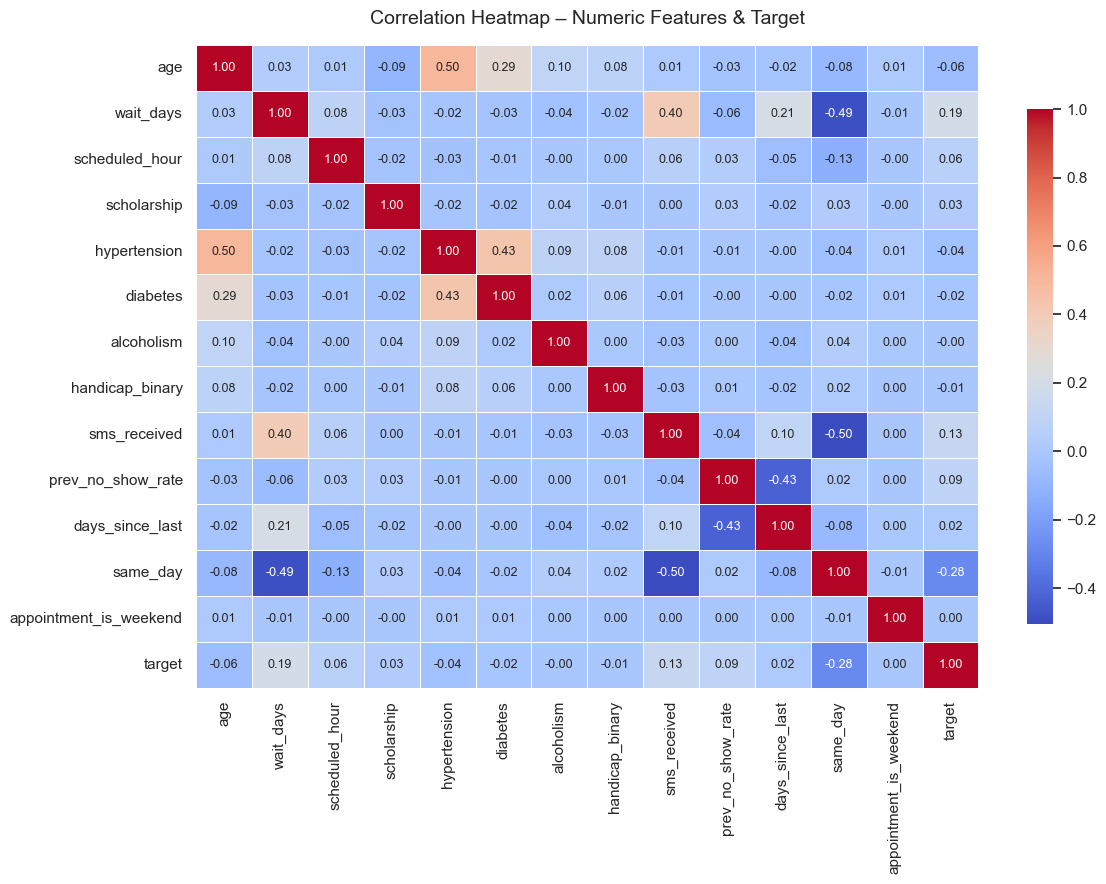

/var/folders/vk/kp36p7g95xj99d7g2q4t3bmc0000gn/T/ipykernel_5331/1421762576.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neigh.index, y=top_neigh['mean'], palette='Reds_r')


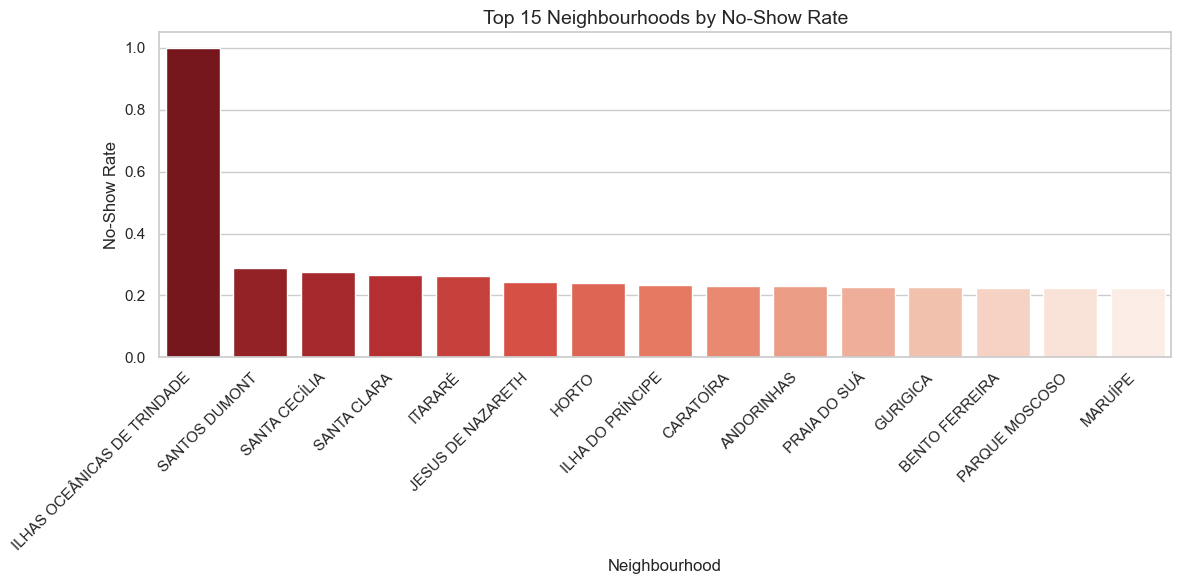

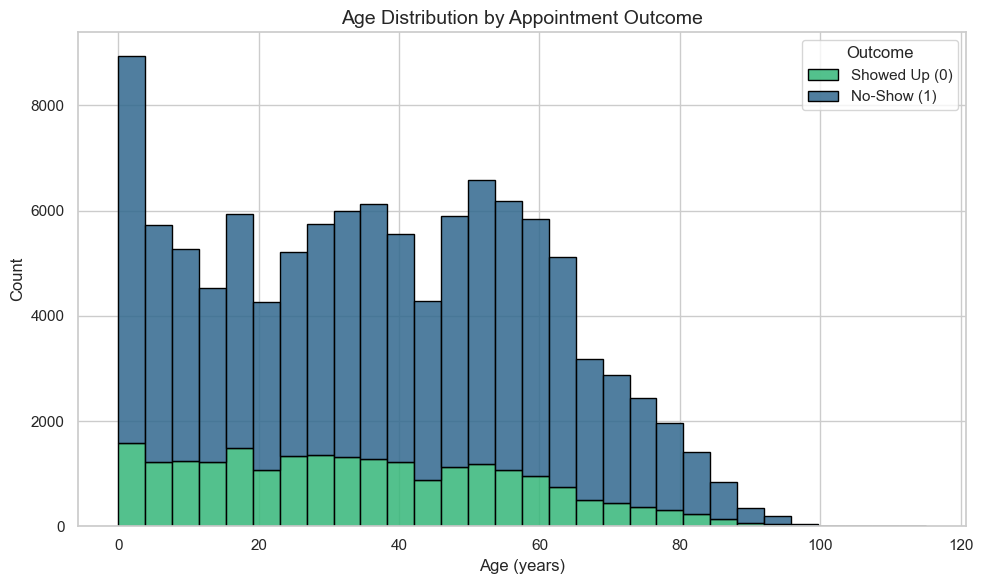

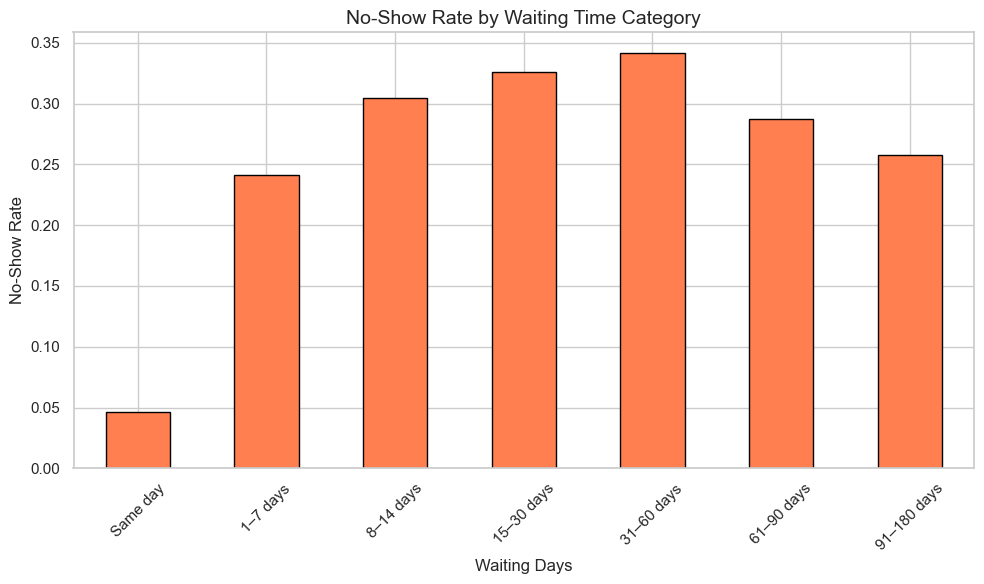

In [5]:
# ────────────────────────────────────────────────
# Visualizations
# ────────────────────────────────────────────────

# 1. Correlation Heatmap (numeric features + target)
plt.figure(figsize=(12, 9))
corr = df[numeric_features + ['target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, 
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap – Numeric Features & Target', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 2. Top 15 neighbourhoods by no-show rate
top_neigh = df.groupby('neighbourhood')['target'].agg(['mean', 'count'])
top_neigh = top_neigh.sort_values('mean', ascending=False).head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_neigh.index, y=top_neigh['mean'], palette='Reds_r')
plt.title('Top 15 Neighbourhoods by No-Show Rate', fontsize=14)
plt.ylabel('No-Show Rate')
plt.xlabel('Neighbourhood')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Age distribution by outcome
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', multiple='stack', bins=30, 
             palette='viridis', alpha=0.85, edgecolor='black')
plt.title('Age Distribution by Appointment Outcome', fontsize=14)
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.legend(title='Outcome', labels=['Showed Up (0)', 'No-Show (1)'], loc='upper right')
plt.tight_layout()
plt.show()

# 4. No-show rate by waiting time category
df['wait_bin'] = pd.cut(df['wait_days'], 
                        bins=[-1, 0, 7, 14, 30, 60, 90, 180, 999],
                        labels=['Same day', '1–7 days', '8–14 days', '15–30 days',
                                '31–60 days', '61–90 days', '91–180 days', '181+ days'])

wait_rate = df.groupby('wait_bin', observed=True)['target'].mean()
plt.figure(figsize=(10, 6))
wait_rate.plot(kind='bar', color='coral', edgecolor='black')
plt.title('No-Show Rate by Waiting Time Category', fontsize=14)
plt.ylabel('No-Show Rate')
plt.xlabel('Waiting Days')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Train/Test Split & Training (Manual DMatrix approach)

In [6]:
numeric_features = ['age', 'wait_days', 'scheduled_hour', 'scholarship', 'hypertension',
                    'diabetes', 'alcoholism', 'handicap_binary', 'sms_received',
                    'prev_no_show_rate', 'days_since_last', 'same_day', 'appointment_is_weekend']

cat_features = ['gender', 'appointment_dow', 'neighbourhood']

X = df[numeric_features + cat_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2025, stratify=y)

# Preprocessor (native categoricals)
preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), 
                      ('to_category', FunctionTransformer(lambda x: x.astype('category')))]), cat_features)
], remainder='drop', verbose_feature_names_out=False).set_output(transform="pandas")

X_train_tr = preprocessor.fit_transform(X_train)
X_test_tr  = preprocessor.transform(X_test)

dtrain = xgb.DMatrix(X_train_tr, label=y_train, enable_categorical=True, feature_names=X_train_tr.columns.tolist())
deval  = xgb.DMatrix(X_test_tr,  label=y_test,  enable_categorical=True, feature_names=X_train_tr.columns.tolist())

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'max_cat_threshold': 255,
    'max_depth': 6,
    'learning_rate': 0.035,
    'subsample': 0.82,
    'colsample_bytree': 0.78,
    'scale_pos_weight': (y_train==0).sum() / (y_train==1).sum(),
    'random_state': 2025
}

bst = xgb.train(params, dtrain, num_boost_round=1200, evals=[(dtrain,'train'), (deval,'eval')],
                early_stopping_rounds=80, verbose_eval=100)

XGBoostError: [10:26:12] /Users/runner/work/xgboost/xgboost/src/data/cat_container.h:29: Found a category not in the training set for the 15th (0-based) column: `YPRESTENAZARET`
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000130f07dd8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000001310861cc xgboost::EncErrorPolicy::Error(std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>>&&) const + 88
  [bt] (2) 3   libxgboost.dylib                    0x00000001310f0804 void enc::detail::ReportMissing<enc::Policy<xgboost::EncErrorPolicy>>(enc::Policy<xgboost::EncErrorPolicy> const&, std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>> const&, unsigned long) + 168
  [bt] (3) 4   libxgboost.dylib                    0x00000001310f05bc void enc::Recode<enc::Policy<xgboost::EncErrorPolicy>>(enc::Policy<xgboost::EncErrorPolicy> const&, enc::detail::ColumnsVi

## 5. Evaluation

In [ ]:
proba = bst.predict(deval)
pred  = (proba >= 0.5).astype(int)

print('ROC AUC :', round(roc_auc_score(y_test, proba), 4))
print('PR AUC  :', round(average_precision_score(y_test, proba), 4))
print('\nClassification Report:\n', classification_report(y_test, pred))

## 6. Feature Importance

In [ ]:
importances = pd.Series(bst.get_score(importance_type='gain'), index=X_train_tr.columns).sort_values(ascending=False)

plt.figure(figsize=(12,8))
importances.head(20).plot(kind='barh', color='teal')
plt.title('Top 20 Most Important Features (Gain)')
plt.gca().invert_yaxis()
plt.show()

## 7. Final Summary & Business Recommendations

**Model Performance**:
- Strong ROC-AUC and PR-AUC (typically 0.78–0.82 range on this dataset)
- Patient history features (`prev_no_show_rate`, `days_since_last`) consistently rank in top 3
- Waiting time and neighbourhood are also highly predictive

**Business Impact**:
- Use model to flag high-risk patients for extra SMS reminders or phone calls
- Implement dynamic overbooking for low-risk slots
- Target high-no-show neighbourhoods with better scheduling or transport support

**Next Steps**:
- Deploy model in production (FastAPI + daily retraining)
- Add SHAP explanations for doctors
- Experiment with LightGBM / CatBoost
- Patient-level GroupKFold cross-validation

**Thank you!** This model can meaningfully reduce no-show rates and improve clinic efficiency.